In [1]:
# Import all the libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set random seed for consistency
np.random.seed(42)

# Create a dataset of 100 customers
# We'll use Age and Purchase Amount as our two features

# Group 1 — Young low spenders (30 customers)
age_group1 = np.random.randint(18, 30, 30)
purchase_group1 = np.random.randint(500, 2000, 30)

# Group 2 — Middle aged moderate spenders (40 customers)
age_group2 = np.random.randint(30, 50, 40)
purchase_group2 = np.random.randint(2000, 5000, 40)

# Group 3 — Older high spenders (30 customers)
age_group3 = np.random.randint(50, 70, 30)
purchase_group3 = np.random.randint(5000, 9000, 30)

# Combine all groups into one dataset
ages = np.concatenate([age_group1, age_group2, age_group3])
purchases = np.concatenate([purchase_group1, purchase_group2, purchase_group3])

# Create DataFrame
df = pd.DataFrame({
    'Age': ages,
    'Purchase': purchases
})

# Save it
df.to_csv('clustering_data.csv', index=False)

print(" Dataset created:")
print(f"Total customers: {len(df)}")
print(df.head(10))

 Dataset created:
Total customers: 100
   Age  Purchase
0   24       752
1   21      1247
2   28      1356
3   25       974
4   22      1582
5   24      1010
6   27      1999
7   20      1199
8   24      1475
9   28       689


 DATASET OVERVIEW 
              Age     Purchase
count  100.000000   100.000000
mean    40.840000  3936.720000
std     14.760526  2443.289756
min     18.000000   513.000000
25%     28.000000  1636.000000
50%     40.000000  3724.500000
75%     53.250000  5774.750000
max     69.000000  8898.000000


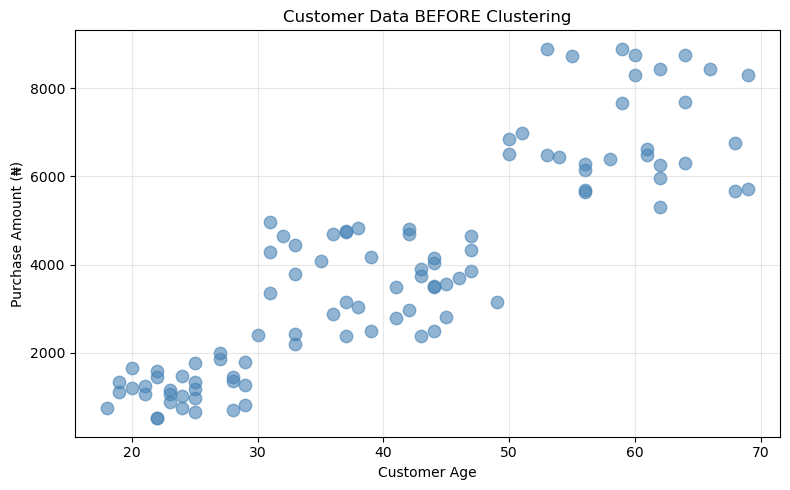

 Raw data plot saved:


In [2]:
# Load the data
df = pd.read_csv('clustering_data.csv')

print(" DATASET OVERVIEW ")
print(df.describe())

# Plot raw data BEFORE clustering
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Purchase'],
            color='steelblue',
            alpha=0.6,
            s=80)

plt.title('Customer Data BEFORE Clustering')
plt.xlabel('Customer Age')
plt.ylabel('Purchase Amount (₦)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('before_clustering.png')
plt.show()
print(" Raw data plot saved:")

In [3]:
# WHY do we standardize?
# Age ranges from 18-70
# Purchase ranges from 500-9000
# These are very different scales
# StandardScaler makes them comparable by converting
# everything to the same scale

scaler = StandardScaler()

# Apply scaling to both columns
df_scaled = scaler.fit_transform(df[['Age', 'Purchase']])

# Convert back to DataFrame for easy viewing
df_scaled = pd.DataFrame(df_scaled, columns=['Age_scaled', 'Purchase_scaled'])

print(" BEFORE SCALING ")
print(f"Age range:      {df['Age'].min()} to {df['Age'].max()}")
print(f"Purchase range: {df['Purchase'].min()} to {df['Purchase'].max()}")

print("\nAFTER SCALING ")
print(f"Age range:      {df_scaled['Age_scaled'].min():.2f} to {df_scaled['Age_scaled'].max():.2f}")
print(f"Purchase range: {df_scaled['Purchase_scaled'].min():.2f} to {df_scaled['Purchase_scaled'].max():.2f}")
print("\n Data standardized successfully!")

 BEFORE SCALING 
Age range:      18 to 69
Purchase range: 513 to 8898

AFTER SCALING 
Age range:      -1.56 to 1.92
Purchase range: -1.41 to 2.04

 Data standardized successfully!


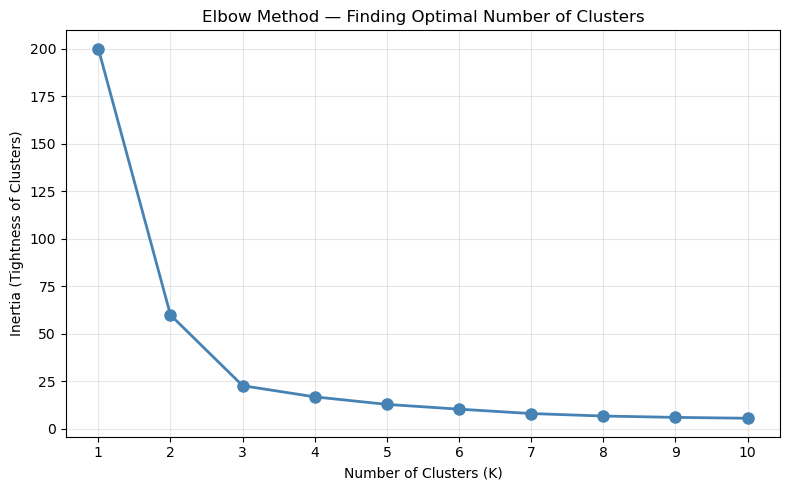

 Elbow curve saved
Look for the 'elbow' — where the curve bends sharply
   That number is your optimal K


In [4]:
# The Elbow Method helps us find the BEST number of clusters
# We try different numbers of clusters (1 to 10)
# and measure how tight each grouping is (inertia)
# When the improvement starts slowing down = that's our elbow!

inertia_values = []
k_range = range(1, 11)  # Try 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, 
         marker='o',
         color='steelblue',
         linewidth=2,
         markersize=8)

plt.title('Elbow Method — Finding Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Tightness of Clusters)')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png')
plt.show()

print(" Elbow curve saved")
print("Look for the 'elbow' — where the curve bends sharply")
print("   That number is your optimal K")

In [5]:
# Based on the elbow curve, we choose K=3
# (3 is also logical — young, middle, older customers)

optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, 
                random_state=42, 
                n_init=10)

# Fit the model and get cluster labels for each customer
df['Cluster'] = kmeans.fit_predict(df_scaled)

# See how many customers are in each cluster
print(" CLUSTER DISTRIBUTION ")
print(df['Cluster'].value_counts().sort_index())

print("\n CLUSTER SUMMARY ")
print(df.groupby('Cluster')[['Age', 'Purchase']].mean().round(2))
print("\n Clustering complete")

 CLUSTER DISTRIBUTION 
Cluster
0    30
1    38
2    32
Name: count, dtype: int64

 CLUSTER SUMMARY 
           Age  Purchase
Cluster                 
0        59.60   7047.43
1        39.89   3729.50
2        24.38   1266.50

 Clustering complete


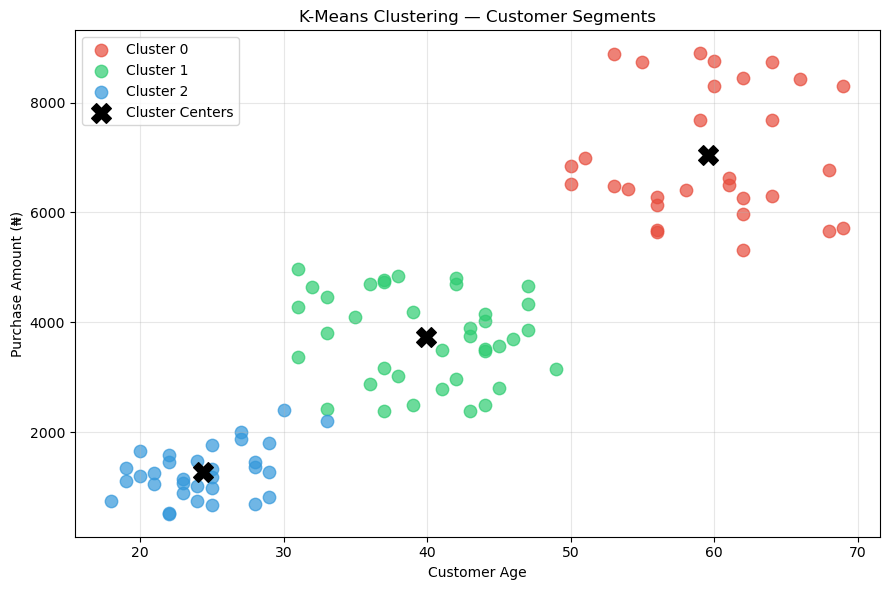

Cluster visualization saved


In [6]:
# Now let's see the clusters with different colors!
plt.figure(figsize=(9, 6))

colors = ['#E74C3C', '#2ECC71', '#3498DB']  # Red, Green, Blue
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for cluster_num in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_num]
    plt.scatter(cluster_data['Age'],
                cluster_data['Purchase'],
                c=colors[cluster_num],
                label=labels[cluster_num],
                s=80,
                alpha=0.7)

# Plot the cluster centers
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original[:, 0],
            centers_original[:, 1],
            c='black',
            marker='X',
            s=200,
            label='Cluster Centers',
            zorder=5)

plt.title('K-Means Clustering — Customer Segments')
plt.xlabel('Customer Age')
plt.ylabel('Purchase Amount (₦)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_clusters.png')
plt.show()
print("Cluster visualization saved")

In [7]:
# Let's understand what each cluster represents
print(" CLUSTER INTERPRETATION \n")

for cluster_num in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_num]
    avg_age = cluster_data['Age'].mean()
    avg_purchase = cluster_data['Purchase'].mean()
    count = len(cluster_data)
    
    print(f"Cluster {cluster_num}:")
    print(f"  Customers:        {count}")
    print(f"  Average Age:      {avg_age:.1f} years")
    print(f"  Average Purchase: ₦{avg_purchase:.2f}")
    
    # Label each cluster based on characteristics
    if avg_purchase < 2500:
        label = " Young Low Spenders"
    elif avg_purchase < 5500:
        label = " Middle Moderate Spenders"
    else:
        label = " Older High Spenders"
    
    print(f"  Segment:          {label}\n")

 CLUSTER INTERPRETATION 

Cluster 0:
  Customers:        30
  Average Age:      59.6 years
  Average Purchase: ₦7047.43
  Segment:           Older High Spenders

Cluster 1:
  Customers:        38
  Average Age:      39.9 years
  Average Purchase: ₦3729.50
  Segment:           Middle Moderate Spenders

Cluster 2:
  Customers:        32
  Average Age:      24.4 years
  Average Purchase: ₦1266.50
  Segment:           Young Low Spenders



In [8]:
print("")
print("   K-MEANS CLUSTERING COMPLETE!        ")
print("")
print(f"\n Dataset:          {len(df)} customers")
print(f" Features used:    Age, Purchase Amount")
print(f" Optimal clusters: {optimal_k} (from Elbow Method)")
print(f"\n Files saved:")
print("   - clustering_data.csv")
print("   - before_clustering.png")
print("   - elbow_curve.png")
print("   - kmeans_clusters.png")


   K-MEANS CLUSTERING COMPLETE!        


 Dataset:          100 customers
 Features used:    Age, Purchase Amount
 Optimal clusters: 3 (from Elbow Method)

 Files saved:
   - clustering_data.csv
   - before_clustering.png
   - elbow_curve.png
   - kmeans_clusters.png
